# Lab 03: Exploring Neural Information Processing  
**Name:** Eduardo Cabrera-Lopez  
**Course:** ITAI 4374 – Neuroscience as a Model for AI Systems  

## Overview
In this lab, I implemented and analyzed both biological and artificial neuron models.
The goal was to understand how each system processes information and how biological
principles can inspire artificial intelligence systems.

## Part 1: Biological Neuron Simulation

In this section, I implemented a simplified biological neuron model that simulates
membrane potential changes over time. The neuron fires when the threshold is reached,
representing an action potential.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class BiologicalNeuron:
    """Simulates basic biological neuron characteristics"""

    def __init__(self, resting_potential=-70, threshold=-55, peak_potential=40, decay=0.5):
        self.resting_potential = resting_potential
        self.threshold = threshold
        self.peak_potential = peak_potential
        self.decay = decay

    def simulate_response(self, input_current, time_steps=100):
        membrane_potential = self.resting_potential
        membrane_potentials = []
        spikes = []

        for t in range(time_steps):
            membrane_potential += input_current

            if membrane_potential >= self.threshold:
                membrane_potential = self.peak_potential
                spikes.append(t)

            membrane_potentials.append(membrane_potential)

            # Decay back toward resting potential
            if membrane_potential > self.resting_potential:
                membrane_potential -= self.decay * (membrane_potential - self.resting_potential) * 0.2

        return membrane_potentials, spikes

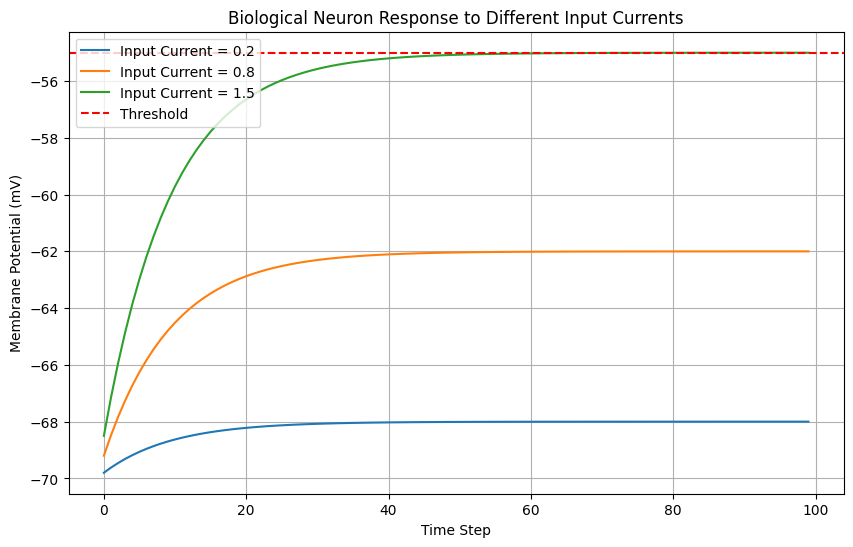

In [3]:
bio_neuron = BiologicalNeuron()

input_currents = [0.2, 0.8, 1.5]

plt.figure(figsize=(10, 6))

for current in input_currents:
    membrane_potentials, spikes = bio_neuron.simulate_response(current)
    plt.plot(membrane_potentials, label=f'Input Current = {current}')

plt.axhline(y=bio_neuron.threshold, color='r', linestyle='--', label='Threshold')
plt.xlabel("Time Step")
plt.ylabel("Membrane Potential (mV)")
plt.title("Biological Neuron Response to Different Input Currents")
plt.legend()
plt.grid(True)
plt.show()

### Analysis of Biological Neuron Response

- When the input current is low, the membrane potential stays near the resting value.
- As the input current increases, the membrane potential rises faster.
- When the threshold is reached, the neuron generates a spike (action potential).
- This demonstrates the **all-or-none principle**, where neurons either fire or do not fire.

This shows that biological neurons process information over time and depend on input strength.

## Part 2: Artificial Neuron Implementation

In this section, I implemented an artificial neuron using weights, bias, and activation functions.
This model represents how neural networks process information mathematically.

In [4]:
class ArtificialNeuron:
    """Implements artificial neuron for comparison"""

    def __init__(self, num_inputs):
        self.weights = np.random.randn(num_inputs)
        self.bias = np.random.randn()

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def relu(self, x):
        return np.maximum(0, x)

    def tanh(self, x):
        return np.tanh(x)

    def activate(self, inputs, activation='sigmoid'):
        weighted_sum = np.dot(self.weights, inputs) + self.bias

        if activation == 'sigmoid':
            return self.sigmoid(weighted_sum)
        elif activation == 'relu':
            return self.relu(weighted_sum)
        elif activation == 'tanh':
            return self.tanh(weighted_sum)
        else:
            raise ValueError("Unsupported activation function")

In [5]:
art_neuron = ArtificialNeuron(3)
inputs = np.array([0.5, 0.2, 0.8])

print("Weights:", art_neuron.weights)
print("Bias:", art_neuron.bias)
print("Sigmoid Output:", art_neuron.activate(inputs, activation='sigmoid'))
print("ReLU Output:", art_neuron.activate(inputs, activation='relu'))
print("Tanh Output:", art_neuron.activate(inputs, activation='tanh'))

Weights: [ 0.37729649  0.05084009 -0.76303417]
Bias: -1.0622390689254095
Sigmoid Output: 0.18635811704271443
ReLU Output: 0.0
Tanh Output: -0.900309369078964


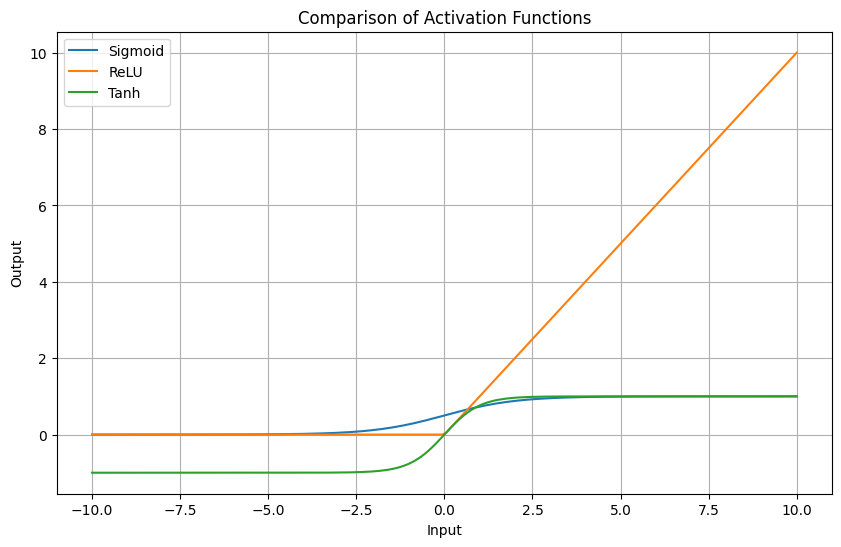

In [6]:
x = np.linspace(-10, 10, 200)

sigmoid_y = 1 / (1 + np.exp(-x))
relu_y = np.maximum(0, x)
tanh_y = np.tanh(x)

plt.figure(figsize=(10, 6))
plt.plot(x, sigmoid_y, label='Sigmoid')
plt.plot(x, relu_y, label='ReLU')
plt.plot(x, tanh_y, label='Tanh')
plt.xlabel("Input")
plt.ylabel("Output")
plt.title("Comparison of Activation Functions")
plt.legend()
plt.grid(True)
plt.show()

### Analysis of Activation Functions

- The **sigmoid function** compresses outputs between 0 and 1.
- The **ReLU function** removes negative values and keeps positive values.
- The **tanh function** produces outputs between -1 and 1.

Each activation function changes how the neuron responds to inputs,
which affects learning and performance in neural networks.

## Part 3: Neural Network Simulation

In this section, I created simple networks of biological and artificial neurons
to observe how information is processed across multiple neurons.

In [7]:
class SimpleBiologicalNetwork:
    def __init__(self, num_neurons):
        self.neurons = [BiologicalNeuron() for _ in range(num_neurons)]

    def simulate(self, input_currents, time_steps=100):
        all_outputs = []

        for neuron, current in zip(self.neurons, input_currents):
            membrane_potentials, spikes = neuron.simulate_response(current, time_steps)
            all_outputs.append(membrane_potentials)

        return np.array(all_outputs)

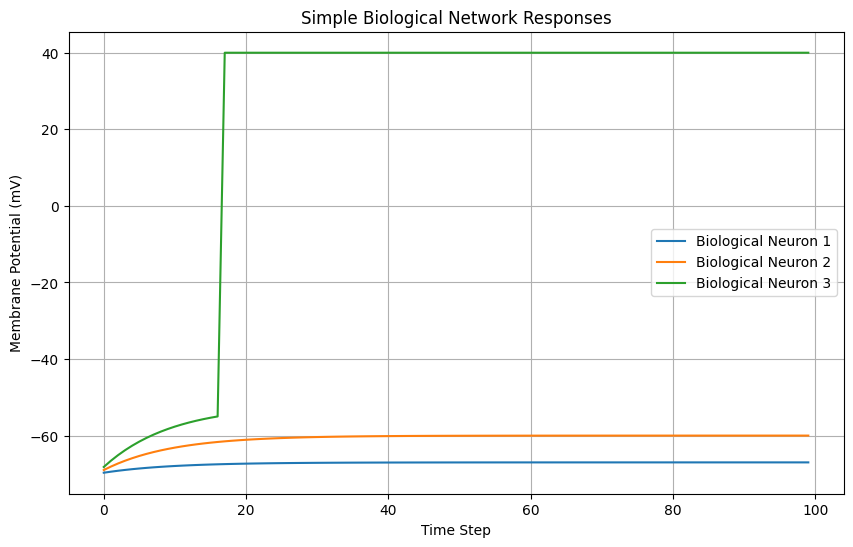

In [8]:
bio_network = SimpleBiologicalNetwork(3)
bio_outputs = bio_network.simulate([0.3, 1.0, 1.8], time_steps=100)

plt.figure(figsize=(10, 6))
for i in range(len(bio_outputs)):
    plt.plot(bio_outputs[i], label=f'Biological Neuron {i+1}')

plt.xlabel("Time Step")
plt.ylabel("Membrane Potential (mV)")
plt.title("Simple Biological Network Responses")
plt.legend()
plt.grid(True)
plt.show()

### Biological Network Analysis

- Each neuron responds differently depending on input current.
- Stronger inputs produce larger membrane potential changes.
- The network shows time-based behavior similar to real neural systems.

In [9]:
class SimpleArtificialNetwork:
    def __init__(self, input_size, hidden_size, output_size):
        self.hidden_layer = [ArtificialNeuron(input_size) for _ in range(hidden_size)]
        self.output_layer = [ArtificialNeuron(hidden_size) for _ in range(output_size)]

    def forward(self, inputs, activation='sigmoid'):
        hidden_outputs = np.array([neuron.activate(inputs, activation) for neuron in self.hidden_layer])
        final_outputs = np.array([neuron.activate(hidden_outputs, activation) for neuron in self.output_layer])
        return hidden_outputs, final_outputs

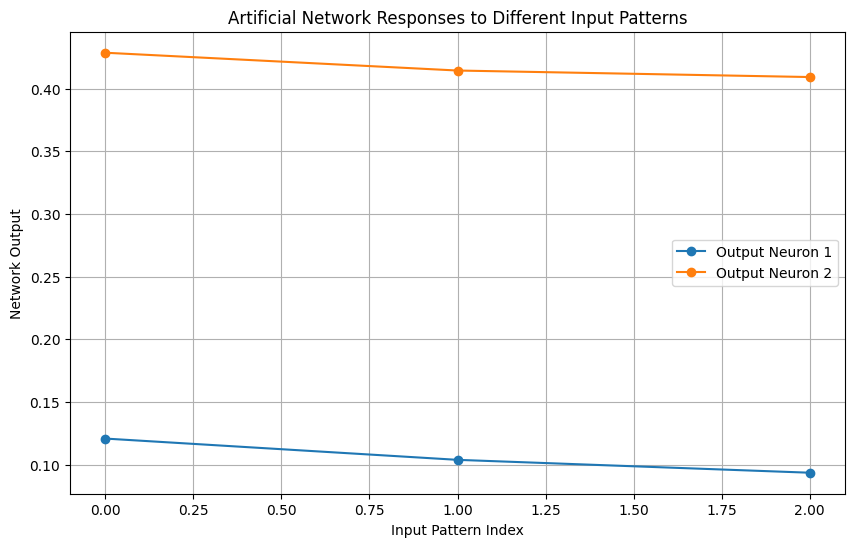

In [10]:
art_network = SimpleArtificialNetwork(input_size=3, hidden_size=4, output_size=2)

test_inputs = [
    np.array([0.1, 0.2, 0.3]),
    np.array([0.5, 0.5, 0.5]),
    np.array([1.0, 0.8, 0.6])
]

outputs = []

for inp in test_inputs:
    hidden_out, final_out = art_network.forward(inp, activation='sigmoid')
    outputs.append(final_out)

outputs = np.array(outputs)

plt.figure(figsize=(10, 6))
for i in range(outputs.shape[1]):
    plt.plot(outputs[:, i], marker='o', label=f'Output Neuron {i+1}')

plt.xlabel("Input Pattern Index")
plt.ylabel("Network Output")
plt.title("Artificial Network Responses to Different Input Patterns")
plt.legend()
plt.grid(True)
plt.show()

### Artificial Network Analysis

- The artificial network produces outputs instantly.
- Different input patterns result in different outputs.
- The network combines information using weighted sums and activation functions.

## Comparison of Biological and Artificial Neurons

Biological neurons process information over time using membrane potentials and action potentials (spikes). Their behavior depends on reaching a threshold, and they follow the all-or-none principle.

Artificial neurons, on the other hand, process inputs instantly using weighted sums and activation functions such as sigmoid, ReLU, or tanh. They produce continuous outputs rather than discrete spikes.

Key Differences:
- Biological neurons are time-dependent, while artificial neurons are instantaneous.
- Biological neurons rely on electrochemical signals, while artificial neurons use mathematical computations.
- Artificial neurons are simplified models designed for efficiency and scalability.

Overall, artificial neurons are inspired by biological neurons but do not fully capture their complexity. However, studying biological systems can help improve future AI models.

## Conclusion

This lab demonstrated that biological neurons and artificial neurons both transform inputs
into outputs, but they operate very differently. Biological neurons rely on time-based
electrical signals, while artificial neurons use mathematical functions. Understanding
these differences can help improve future AI systems by incorporating more realistic
neural behaviors.